In [45]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import random_split
from torchvision import datasets
from torchvision import transforms
import torch.nn.functional as F
import time
import numpy as np


In [46]:
# Device
DEVICE = torch.device("mps")

# Hyperparameters
LEARNING_RATE = 0.0005
BATCH_SIZE = 32
NUM_EPOCHS = 30



In [47]:
def get_dataloaders_mnist(batch_size, num_workers=0,
                          validation_fraction=None,
                          train_transforms=None, test_transforms=None):

    if train_transforms is None:
        train_transforms = transforms.ToTensor()

    if test_transforms is None:
        test_transforms = transforms.ToTensor()

    train_dataset = datasets.MNIST(root='data',
                                   train=True,
                                   transform=train_transforms,
                                   download=True)

    valid_dataset = datasets.MNIST(root='data',
                                   train=True,
                                   transform=test_transforms)

    test_dataset = datasets.MNIST(root='data',
                                  train=False,
                                  transform=test_transforms)

    if validation_fraction is not None:
        num = int(validation_fraction * 60000)
        train_indices = torch.arange(0, 60000 - num)
        valid_indices = torch.arange(60000 - num, 60000)

        train_sampler = SubsetRandomSampler(train_indices)
        valid_sampler = SubsetRandomSampler(valid_indices)

        valid_loader = DataLoader(dataset=valid_dataset,
                                  batch_size=batch_size,
                                  num_workers=num_workers,
                                  sampler=valid_sampler)

        train_loader = DataLoader(dataset=train_dataset,
                                  batch_size=batch_size,
                                  num_workers=num_workers,
                                  drop_last=True,
                                  sampler = train_sampler)
    else:
        train_loader = DataLoader(dataset = train_dataset,
                                batch_size = batch_size,
                                num_workers = num_workers,
                                shuffle = False)
    test_loader = DataLoader(dataset = test_dataset,
                            batch_size = batch_size,
                            num_workers = num_workers,
                            shuffle =False)
    if validation_fraction is None:
        return train_loader, test_loader
    else :
        return train_loader, valid_loader, test_loader

In [48]:
train_loader, valid_loader, test_loader = get_dataloaders_mnist(
    batch_size = BATCH_SIZE,
    num_workers = 2,
    validation_fraction = 0.
)

In [49]:
# 데이터셋 체크
print('Training Set:\n')
for images, labels in train_loader:
    print('Image batch dimensions: ', images.size())
    print('Image label dimensions: ', labels.size())
    print(labels[:10])
    break
# 데이터셋 체크
print('\n Validation Set:\n')
for images, labels in valid_loader:
    print('Image batch dimensions: ', images.size())
    print('Image label dimensions: ', labels.size())
    print(labels[:10])
    break
# 데이터셋 체크
print('\n Testing Set:\n')
for images, labels in test_loader:
    print('Image batch dimensions: ', images.size())
    print('Image label dimensions: ', labels.size())
    print(labels[:10])
    break

Training Set:

Image batch dimensions:  torch.Size([32, 1, 28, 28])
Image label dimensions:  torch.Size([32])
tensor([1, 5, 7, 2, 1, 0, 6, 3, 2, 4])

 Validation Set:


 Testing Set:

Image batch dimensions:  torch.Size([32, 1, 28, 28])
Image label dimensions:  torch.Size([32])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


In [50]:
################
# MODEL
################

class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)

class Trim(nn.Module):
    def __init__(self, *args):
        super().__init__()
    def forward(self, x):
        return x[:,:,:28,:28]

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, stride = (1,1), kernel_size =(3,3), padding = 1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(32,64, stride = (2,2), kernel_size = (3,3), padding = 1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64,64, stride = (2,2), kernel_size = (3,3), padding = 1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64,64, stride = (1,1), kernel_size = (3,3), padding = 1),
            nn.Flatten(),
            nn.Linear(3136,2)
        )
        self.decoder = nn.Sequential(
            torch.nn.Linear(2,3136),
            Reshape(-1,64, 7, 7),
            nn.ConvTranspose2d(64,64,stride = (1,1), kernel_size=(3,3), padding = 1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64,64, stride = (2,2), kernel_size=(3,3), padding = 1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64,32, stride = (2,2), kernel_size= (3,3), padding = 0),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32,1, stride = (1,1), kernel_size = (3,3) ,padding = 0),
            Trim(),
            nn.Sigmoid()
        )
    
    def forward(self, x) : 
        x = self.encoder(x)
        x = self.decoder(x)
        return x



In [51]:
model = AutoEncoder()
model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [52]:
def compute_epoch_loss_autoencoder(model, data_loader, loss_fn, device):
    model.eval()
    curr_loss, num_examples =0., 0
    with torch.no_grad():
        for features, _ in data_loader:
            features = features.to(device)
            logits = model(features)
            loss = loss_fn(logits, features, reduction = 'sum')
            num_examples += fratures.size(0)
            curr_loss += loss
        
        curr_loss - curr_loss / num_examples
        return curr_loss

def train_autoencoder(num_epochs, model, optimizer, device, train_loader, loss_fn = None, logging_interval = 100, skip_epoch_stats=False, save_model = None):
    log_dict = {'train_loss_per_batch': [],
                'train_loss_per_epoch': []}
    if loss_fn is None:
        loss_fn = F.mse_loss
    start_time = time.time()
    for epoch in range(num_epochs):
        model.train()
        for batch_idx,(features, _) in enumerate(train_loader):
            features = features.to(device)

            #순전파
            logits = model(features)
            loss = loss_fn(logits,features)
            optimizer.zero_grad()
            #역전파
            loss.backward()

            #모델 파라미터 업데이트
            optimizer.step()

            #로깅
            log_dict['train_loss_per_batch'].append(loss.item())

            if not batch_idx % logging_interval:
                print('Epoch: %03d/%03d | Batch %04d/%04d | Loss: %0.4f' % (epoch+1, num_epochs, batch_idx, len(train_loader), loss))
        if not skip_epoch_stats:
            model_eval()
            with torch.set_grad_enabled(False): #메모리
                train_loss = compute_epoch_loss_autoencoder(model, train_loader, loss_fn, device)
                print('***Epoch: %03d/%03d | Loss : %.3f' %(epoch+1, num_epochs, train_loss))
                log_dict['train_loss_per_epoch'].append(train_loss.item())
        print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
    print('Total Training Time : %.2f min:' % ((time.time() - start_time)/60))
    if save_model is not None:
        torch.save(model.state_dict(), save_model)
    return log_dict

In [53]:
#트레이닝
log_dict = train_autoencoder(num_epochs = NUM_EPOCHS, model = model, optimizer = optimizer, device = DEVICE, train_loader = train_loader, skip_epoch_stats = True, logging_interval =250)

Epoch: 001/030 | Batch 0000/1875 | Loss: 0.2889
Epoch: 001/030 | Batch 0250/1875 | Loss: 0.1039
Epoch: 001/030 | Batch 0500/1875 | Loss: 0.0622
Epoch: 001/030 | Batch 0750/1875 | Loss: 0.0525
Epoch: 001/030 | Batch 1000/1875 | Loss: 0.0503
Epoch: 001/030 | Batch 1250/1875 | Loss: 0.0545
Epoch: 001/030 | Batch 1500/1875 | Loss: 0.0471
Epoch: 001/030 | Batch 1750/1875 | Loss: 0.0505
Time elapsed: 0.25 min
Epoch: 002/030 | Batch 0000/1875 | Loss: 0.0511
Epoch: 002/030 | Batch 0250/1875 | Loss: 0.0519
Epoch: 002/030 | Batch 0500/1875 | Loss: 0.0465
Epoch: 002/030 | Batch 0750/1875 | Loss: 0.0474
Epoch: 002/030 | Batch 1000/1875 | Loss: 0.0459
Epoch: 002/030 | Batch 1250/1875 | Loss: 0.0508
Epoch: 002/030 | Batch 1500/1875 | Loss: 0.0419
Epoch: 002/030 | Batch 1750/1875 | Loss: 0.0421
Time elapsed: 0.49 min
Epoch: 003/030 | Batch 0000/1875 | Loss: 0.0404
Epoch: 003/030 | Batch 0250/1875 | Loss: 0.0413
Epoch: 003/030 | Batch 0500/1875 | Loss: 0.0441
Epoch: 003/030 | Batch 0750/1875 | Loss: 0

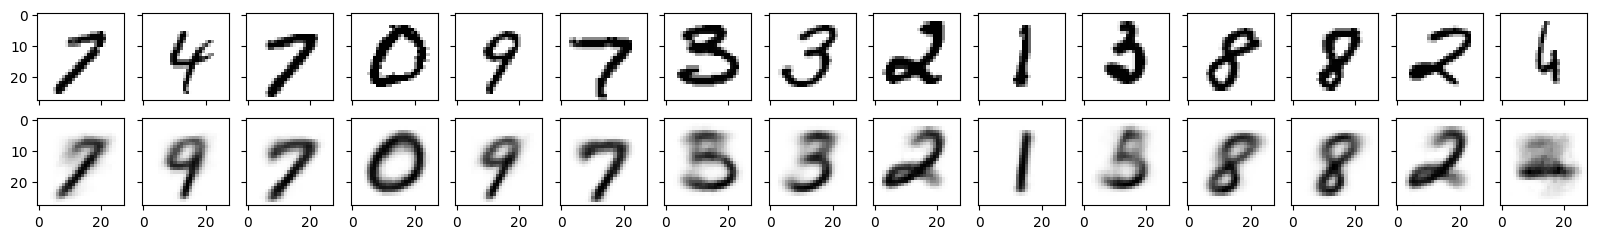

In [54]:
def plot_generated_images(data_loader, model, device,
                          unnormalizer=None,
                          figsize=(20, 2.5), n_images=15, modeltype='autoencoder'):

    fig, axes = plt.subplots(nrows=2, ncols=n_images,
                             sharex=True, sharey=True, figsize=figsize)

    for batch_idx, (features, _) in enumerate(data_loader):

        features = features.to(device)

        color_channels = features.shape[1]
        image_height   = features.shape[2]
        image_width    = features.shape[3]

        with torch.no_grad():
            if modeltype == 'autoencoder':
                decoded_images = model(features)[:n_images]
            elif modeltype == 'VAE':
                encoded, z_mean, z_log_var, decoded_images = model(features)[:n_images]
            else:
                raise ValueError('modeltype not supported')

        orig_images = features[:n_images]
        break

    for i in range(n_images):
        for ax, img in zip(axes, [orig_images, decoded_images]):
            curr_img = img[i].detach().to(torch.device('cpu'))
            if unnormalizer is not None:
                curr_img = unnormalizer(curr_img)

            if color_channels > 1:
                curr_img = np.transpose(curr_img, (1, 2, 0))
                ax[i].imshow(curr_img)
            else:
                ax[i].imshow(curr_img.view((image_height, image_width)), cmap='binary')

plot_generated_images(data_loader=train_loader, model=model, device=DEVICE)
